In [ ]:
# 04_calibration_curve.ipynb — Probability Calibration (Logistic Regression)

## Purpose
Evaluate whether the logistic regression model’s predicted probabilities are **well-calibrated**
(i.e., whether predicted risk matches observed readmission frequency). If probabilities are
over/under-confident, apply post-hoc calibration methods.

## Inputs
- `outputs/06_model_dataset_full.csv`  
  Generated from the SQL pipeline (`run_query.py`) and `sql/06_model_dataset_full.sql`.

## Target
- `readmit_binary`  
  - 1 = readmitted within 30 days (`<30`)  
  - 0 = not readmitted (`NO` or `>30`)

## Why Calibration Matters
A model can have good discrimination (ROC AUC) but still produce probabilities that are too high
or too low. In operational settings (e.g., hospital resource allocation), **calibrated probabilities**
support threshold selection and planning (e.g., “intervene above 20% predicted risk”).

## Approach
1. Train logistic regression model using the same features/preprocessing as the modeling notebook
2. Plot calibration curve (predicted probability vs observed frequency)
3. Compute Brier score (probability error metric; lower is better)
4. Apply calibration layers:
   - Sigmoid / Platt scaling
   - Isotonic regression
5. Compare calibration curves and Brier scores before vs after calibration

## Key Metrics
- ROC AUC (ranking ability; should remain similar after calibration)
- PR AUC / Average Precision (optional; often similar after calibration)
- Brier Score (probability accuracy)
- Calibration Curve (visual diagnostic)

## Output
Calibration plots + metrics comparing:
- Uncalibrated logistic regression
- Sigmoid-calibrated model
- Isotonic-calibrated model

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
import pandas as pd

calib_df = pd.read_csv(
    r"C:\Users\palla\OneDrive\Documents\Coding Projects\Hospital Diabetes Dataset\hospital-readmissions-sql-eda\outputs\06_model_dataset_full.csv"
)

print(calib_df.shape)
calib_df.head()



(101766, 20)


,readmit_binary,age,gender,race,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,A1Cresult,max_glu_serum,insulin,change,diabetesMed,admission_type_id,discharge_disposition_id,admission_source_id
0,0,[0-10),Female,Caucasian,1,41,0,1,0,0,0,1,NaN,NaN,No,No,No,6,25,1
1,0,[10-20),Female,Caucasian,3,59,0,18,0,0,0,9,NaN,NaN,Up,Ch,Yes,1,1,7
2,0,[20-30),Female,AfricanAmerican,2,11,5,13,2,0,1,6,NaN,NaN,No,No,Yes,1,1,7
3,0,[30-40),Male,Caucasian,2,44,1,16,0,0,0,7,NaN,NaN,Up,Ch,Yes,1,1,7
4,0,[40-50),Male,Caucasian,1,51,0,8,0,0,0,5,NaN,NaN,Steady,Ch,Yes,1,1,7


In [3]:
calib_df = calib_df.replace(r"^\s*$", np.nan, regex=True)
X = calib_df.drop(columns=["readmit_binary"])
y = calib_df["readmit_binary"].astype(int)

numeric_cols = [
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

categorical_cols = [c for c in X.columns if c not in numeric_cols]

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_cols),
    ("cat", categorical_pipeline, categorical_cols)
])

logistic_model = LogisticRegression(
    max_iter=3000,
    class_weight="balanced"
)

model_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", logistic_model)
])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model_pipeline.fit(X_train, y_train)

probabilities = model_pipeline.predict_proba(X_test)[:, 1]

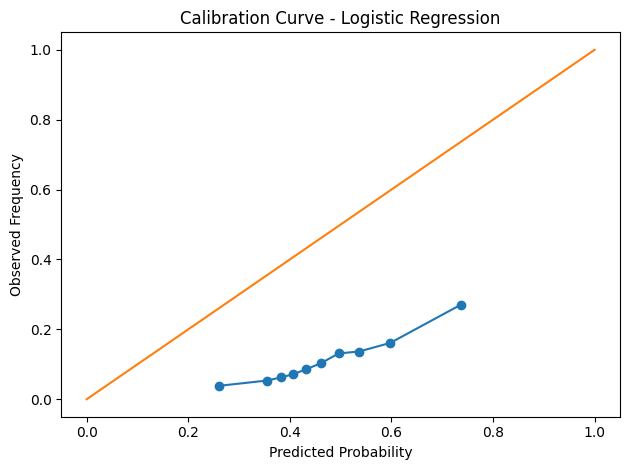

Brier Score: 0.2258


In [6]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

prob_true, prob_pred = calibration_curve(
    y_test,
    probabilities,
    n_bins=10,
    strategy="quantile"
)

plt.figure()
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0, 1], [0, 1])
plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve - Logistic Regression")
plt.tight_layout()
plt.show()

print("Brier Score:", round(brier_score_loss(y_test, probabilities), 4))

In [7]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import brier_score_loss, roc_auc_score, average_precision_score

# ----- baseline (uncalibrated) metrics -----
base_auc = roc_auc_score(y_test, probabilities)
base_pr = average_precision_score(y_test, probabilities)
base_brier = brier_score_loss(y_test, probabilities)

print("Uncalibrated ROC AUC:", round(base_auc, 4))
print("Uncalibrated PR AUC:", round(base_pr, 4))
print("Uncalibrated Brier:", round(base_brier, 4))

# ----- calibrate (sigmoid / Platt scaling) -----
sigmoid_calibrator = CalibratedClassifierCV(model_pipeline, method="sigmoid", cv=5)
sigmoid_calibrator.fit(X_train, y_train)
sigmoid_probs = sigmoid_calibrator.predict_proba(X_test)[:, 1]

print("\nSigmoid-calibrated Brier:", round(brier_score_loss(y_test, sigmoid_probs), 4))
print("Sigmoid-calibrated ROC AUC:", round(roc_auc_score(y_test, sigmoid_probs), 4))
print("Sigmoid-calibrated PR AUC:", round(average_precision_score(y_test, sigmoid_probs), 4))

# ----- calibrate (isotonic) -----
isotonic_calibrator = CalibratedClassifierCV(model_pipeline, method="isotonic", cv=5)
isotonic_calibrator.fit(X_train, y_train)
isotonic_probs = isotonic_calibrator.predict_proba(X_test)[:, 1]

print("\nIsotonic-calibrated Brier:", round(brier_score_loss(y_test, isotonic_probs), 4))
print("Isotonic-calibrated ROC AUC:", round(roc_auc_score(y_test, isotonic_probs), 4))
print("Isotonic-calibrated PR AUC:", round(average_precision_score(y_test, isotonic_probs), 4))

Uncalibrated ROC AUC: 0.675
Uncalibrated PR AUC: 0.2194
Uncalibrated Brier: 0.2258

Sigmoid-calibrated Brier: 0.0948
Sigmoid-calibrated ROC AUC: 0.6751
Sigmoid-calibrated PR AUC: 0.2193

Isotonic-calibrated Brier: 0.0945
Isotonic-calibrated ROC AUC: 0.675
Isotonic-calibrated PR AUC: 0.2185


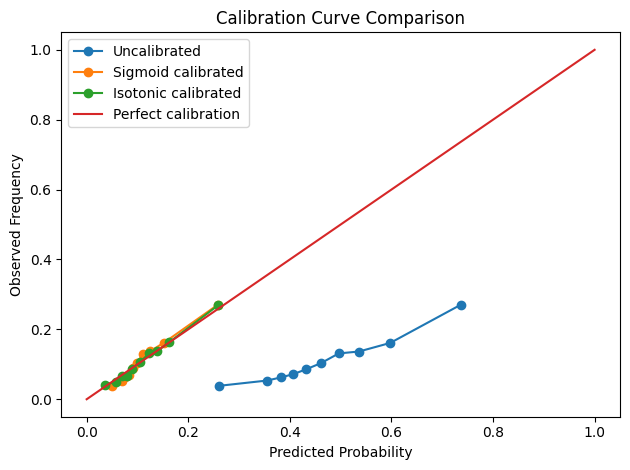

In [8]:
prob_true_base, prob_pred_base = calibration_curve(y_test, probabilities, n_bins=10, strategy="quantile")
prob_true_sig, prob_pred_sig = calibration_curve(y_test, sigmoid_probs, n_bins=10, strategy="quantile")
prob_true_iso, prob_pred_iso = calibration_curve(y_test, isotonic_probs, n_bins=10, strategy="quantile")

plt.figure()
plt.plot(prob_pred_base, prob_true_base, marker="o", label="Uncalibrated")
plt.plot(prob_pred_sig, prob_true_sig, marker="o", label="Sigmoid calibrated")
plt.plot(prob_pred_iso, prob_true_iso, marker="o", label="Isotonic calibrated")
plt.plot([0, 1], [0, 1], label="Perfect calibration")

plt.xlabel("Predicted Probability")
plt.ylabel("Observed Frequency")
plt.title("Calibration Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Summary of Findings — Probability Calibration

## Objective
Assess whether the logistic regression model produces well-calibrated probabilities
and correct any overconfidence through post-hoc calibration.

## Uncalibrated Model

- ROC AUC ≈ 0.675
- PR AUC ≈ 0.219
- Brier Score ≈ 0.226

The calibration curve showed that predicted probabilities were systematically higher
than observed readmission frequencies, indicating overconfidence. This is likely due to
the use of class weighting during training.

## After Calibration

Sigmoid (Platt scaling):
- Brier Score ≈ 0.095
- ROC AUC unchanged

Isotonic regression:
- Brier Score ≈ 0.095
- ROC AUC unchanged

## Interpretation

Calibration substantially improved probability accuracy (Brier score reduction from ~0.226 to ~0.095)
while preserving discrimination (AUC remained stable).

This demonstrates an important modeling principle:

- Discrimination (AUC) measures ranking quality.
- Calibration measures probability reliability.
- Both are necessary for real-world deployment.

## Conclusion

The calibrated logistic regression model provides:

- Strong discrimination
- Reliable probability estimates
- Operationally usable risk scores

For deployment in a healthcare setting, the calibrated model is preferred,
as it supports threshold selection and resource allocation decisions
based on trustworthy predicted probabilities.